# LAB-D1-03 SOLUTION: Shape and Activation Observatory

**INSTRUCTOR ONLY - DO NOT DISTRIBUTE WITH PARTICIPANT MATERIALS**

**Canonical objectives:** `OBJ-D1-02`, `OBJ-D1-05`, `OBJ-D1-06`  
**Reference environment:** local CPU; Python 3.11+; NumPy and matplotlib; no network, download, or GPU  
**Expected compute runtime:** under 10 seconds, including the optional branch  
**Execution contract:** Restart Kernel -> Run All for the full reference path. For the required core-only path, stop at the explicit optional separator; no core cell depends on optional variables.

This solution mirrors the revised participant sequence and completes every required prediction, implementation, diagnosis, deliberate failure, recovery, and explanation. Instructor answers state what happened, why it happened, the concept exposed, likely misconceptions, staged hints, expected evidence, and acceptable alternatives. All extension-only activation material appears after the independently skippable optional separator.

In [1]:
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

SEED = 31
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.figsize": (8, 5), "axes.grid": True, "grid.alpha": 0.22})
print(f"Python {platform.python_version()} | NumPy {np.__version__} | matplotlib {matplotlib.__version__}")
print("Runtime target: local/Colab CPU; no network or GPU required.")

Python 3.11.8 | NumPy 2.4.6 | matplotlib 3.11.1
Runtime target: local/Colab CPU; no network or GPU required.


## Observe: Architecture and Starter State

The architecture is `4 -> 8 -> 3`. Five examples occupy the batch dimension. Under the shared convention, examples are rows and a dense operation is `X @ W + b`.

The supplied matrices are seeded support data, not trained parameters. Your task is to implement and audit the mechanics.

In [2]:
X = np.array([
    [0.5, -1.0, 0.3, 1.2],
    [-0.8, 0.2, 1.1, -0.4],
    [1.5, 0.7, -0.6, 0.1],
    [0.0, -1.3, 0.8, 0.9],
    [-1.1, 1.4, 0.2, -0.7],
])
W1 = rng.normal(0.0, 0.55, size=(4, 8))
b1 = rng.normal(0.0, 0.15, size=(8,))
W2 = rng.normal(0.0, 0.45, size=(8, 3))
b2 = rng.normal(0.0, 0.10, size=(3,))

print("Supplied object shapes:", {"X": X.shape, "W1": W1.shape, "b1": b1.shape, "W2": W2.shape, "b2": b2.shape})

Supplied object shapes: {'X': (5, 4), 'W1': (4, 8), 'b1': (8,), 'W2': (8, 3), 'b2': (3,)}


## Predict: Shapes, Broadcasting, and Parameter Count

Before multiplying arrays, commit to the shapes of `Z1`, `A1`, `logits`, and `probabilities`. Calculate the total trainable parameters and explain whether batch size contributes. Predict what one bias vector does across five examples.

In [3]:
shape_predictions = {
    "Z1": "(5, 8)",
    "A1": "(5, 8)",
    "logits": "(5, 3)",
    "probabilities": "(5, 3)",
    "parameter_count": "(4*8+8) + (8*3+3) = 40+27 = 67",
    "batch_and_broadcasting": "Batch size changes activation rows, not trainable arrays; one b1 vector is reused across all five rows.",
}
assert all(value.strip() for value in shape_predictions.values())
for key, value in shape_predictions.items():
    print(f"{key}: {value}")


Z1: (5, 8)
A1: (5, 8)
logits: (5, 3)
probabilities: (5, 3)
parameter_count: (4*8+8) + (8*3+3) = 40+27 = 67
batch_and_broadcasting: Batch size changes activation rows, not trainable arrays; one b1 vector is reused across all five rows.


### Instructor Answer and Hint Ladder

**Answer:** `Z1/A1=(5,8)`, logits/probabilities `(5,3)`, total parameters `67`. Batch size is not a
parameter dimension; one `(8,)` bias broadcasts across five rows.

**Hints before reveal:** (1) Mark the contracting dimensions. (2) Carry the batch dimension through.
(3) Count stored weights and biases only. (4) Change `B` mentally and ask which parameter arrays change.

**Common wrong answer:** `5*8` additional biases. Broadcasting reuses one vector; it does not create
trainable copies per example.


## Modify: Parameter Count and Dense Broadcasting

Complete the two TODOs. `dense_parameter_count` should count weights plus biases for every adjacent width pair. `dense` should use one batch-first matrix multiplication and one broadcasted bias addition.

In [4]:
def dense_parameter_count(layer_widths):
    widths = [int(width) for width in layer_widths]
    if len(widths) < 2 or any(width <= 0 for width in widths):
        raise ValueError("Layer widths must contain at least two positive integers.")
    return sum(d_in * d_out + d_out for d_in, d_out in zip(widths[:-1], widths[1:]))


def dense(inputs, weights, bias):
    return np.asarray(inputs) @ np.asarray(weights) + np.asarray(bias)


In [5]:
parameter_count = dense_parameter_count([4, 8, 3])
Z1 = dense(X, W1, b1)
Z1_without_bias = X @ W1
broadcast_delta = Z1 - Z1_without_bias

assert parameter_count == 67, "Recheck weights and biases for both layers."
assert Z1.shape == (5, 8)
assert np.allclose(broadcast_delta, np.broadcast_to(b1, Z1.shape))
print("Parameter count:", parameter_count)
print("Z1 shape:", Z1.shape)
print("First two broadcast deltas match the same bias vector:")
print(np.round(broadcast_delta[:2], 3))

Parameter count: 67
Z1 shape: (5, 8)
First two broadcast deltas match the same bias vector:
[[-0.124  0.021  0.14   0.003  0.104  0.047  0.226 -0.301]
 [-0.124  0.021  0.14   0.003  0.104  0.047  0.226 -0.301]]


### Instructor Reference Result

**Expected deterministic result:** parameter count `67`; hidden pre-activation shape `(5,8)`; each
printed broadcast-delta row equals `b1`.

**What happened?** Subtracting `X @ W1` from `X @ W1 + b1` recovered the same bias vector in every row.  
**Why?** NumPy broadcasts `(8,)` across the batch dimension.  
**Concept:** Broadcasting changes computation over examples, not parameter count.


## Predict: Activation Shapes and Extreme Behavior

For the shared input values from `-12` to `12`, predict the output range and the behavior at both extremes for sigmoid, tanh, and ReLU. Predict what a strongly negative matrix will produce after ReLU. State which operations preserve shape.

### Instructor Answer and Hint Ladder

**Answer:** Sigmoid preserves shape and approaches `0`/`1`; tanh preserves shape and approaches `-1`/`1`; ReLU preserves shape, maps negative values to `0`, and passes positive values through. The supplied strongly negative `(5, 8)` matrix should therefore produce 40 zeros under ReLU.

**Hints before reveal:** (1) Treat each function elementwise. (2) Evaluate one negative, zero, and positive value. (3) Separate output range from output shape. (4) State only what this supplied matrix can prove.

**Common wrong answers:** Shape preservation does not mean value preservation. An all-zero result for one matrix is evidence about the current input region, not proof that a unit is permanently dead.

In [6]:
activation_predictions = {
    "sigmoid_range_and_extremes": "Shape preserved; outputs stay in [0, 1], approaching 0 near -12 and 1 near +12.",
    "tanh_range_and_extremes": "Shape preserved; outputs stay in [-1, 1], approaching -1 and +1 at the extremes.",
    "relu_negative_and_positive": "Negative inputs become 0; positive inputs pass through unchanged.",
    "strongly_negative_matrix": "All 40 current ReLU outputs should be zero, which does not prove permanent unit death.",
    "shape_invariant": "All three required elementwise activations preserve the input shape.",
}
assert all(value.strip() for value in activation_predictions.values())
for key, value in activation_predictions.items():
    print(f"{key}: {value}")

sigmoid_range_and_extremes: Shape preserved; outputs stay in [0, 1], approaching 0 near -12 and 1 near +12.
tanh_range_and_extremes: Shape preserved; outputs stay in [-1, 1], approaching -1 and +1 at the extremes.
relu_negative_and_positive: Negative inputs become 0; positive inputs pass through unchanged.
strongly_negative_matrix: All 40 current ReLU outputs should be zero, which does not prove permanent unit death.
shape_invariant: All three required elementwise activations preserve the input shape.


## Modify: Implement Stable Activations

Complete each activation TODO for sigmoid, tanh, and ReLU. Preserve input shape. Sigmoid must remain finite for very large positive and negative values.

In [7]:
def sigmoid(values):
    values = np.asarray(values, dtype=float)
    result = np.empty_like(values)
    nonnegative = values >= 0
    result[nonnegative] = 1.0 / (1.0 + np.exp(-values[nonnegative]))
    exp_values = np.exp(values[~nonnegative])
    result[~nonnegative] = exp_values / (1.0 + exp_values)
    return result


def tanh_activation(values):
    return np.tanh(np.asarray(values, dtype=float))


def relu(values):
    return np.maximum(0.0, np.asarray(values, dtype=float))

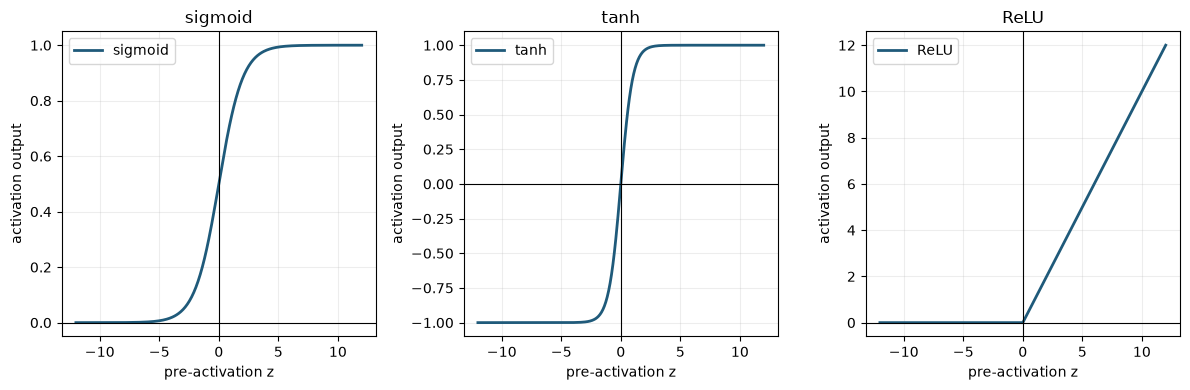

In [8]:
activation_inputs = np.linspace(-12.0, 12.0, 401)
activation_functions = [
    ("sigmoid", sigmoid),
    ("tanh", tanh_activation),
    ("ReLU", relu),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
for ax, (name, function) in zip(axes, activation_functions):
    outputs = function(activation_inputs)
    assert outputs.shape == activation_inputs.shape and np.all(np.isfinite(outputs))
    ax.plot(activation_inputs, outputs, color="#1f5a7a", linewidth=2, label=name)
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.axvline(0.0, color="black", linewidth=0.8)
    ax.set(title=name, xlabel="pre-activation z", ylabel="activation output")
    ax.legend()
plt.tight_layout()
plt.show()

In [9]:
inspection_values = np.array([-12.0, -3.0, 0.0, 3.0, 12.0])
print(f"{'input':>8} {'sigmoid':>10} {'tanh':>10} {'ReLU':>10}")
for index, value in enumerate(inspection_values):
    print(f"{value:>8.1f} {sigmoid(inspection_values)[index]:>10.4f} {tanh_activation(inspection_values)[index]:>10.4f} {relu(inspection_values)[index]:>10.4f}")

extreme_sigmoid = sigmoid(np.array([-1_000_000.0, 0.0, 1_000_000.0]))
assert np.all(np.isfinite(extreme_sigmoid))
assert np.all((0.0 <= extreme_sigmoid) & (extreme_sigmoid <= 1.0))
print("Extreme sigmoid check:", extreme_sigmoid)

   input    sigmoid       tanh       ReLU
   -12.0     0.0000    -1.0000     0.0000
    -3.0     0.0474    -0.9951     0.0000
     0.0     0.5000     0.0000     0.0000
     3.0     0.9526     0.9951     3.0000
    12.0     1.0000     1.0000    12.0000
Extreme sigmoid check: [0.  0.5 1. ]


## Run and Diagnose: Dead Current Region and Saturation

Before running, distinguish these claims: `all outputs for this supplied negative matrix will be zero` and `this unit is permanently dead for every possible input`. Predict which claim the evidence can support. Also predict where sigmoid and tanh output changes will become visually small.

Dead-region evidence: ReLU nonzero outputs = 0/40
Saturation evidence: sigmoid(8)->sigmoid(12) change = 0.000329
Saturation evidence: tanh(8)->tanh(12) change = 0.000000225


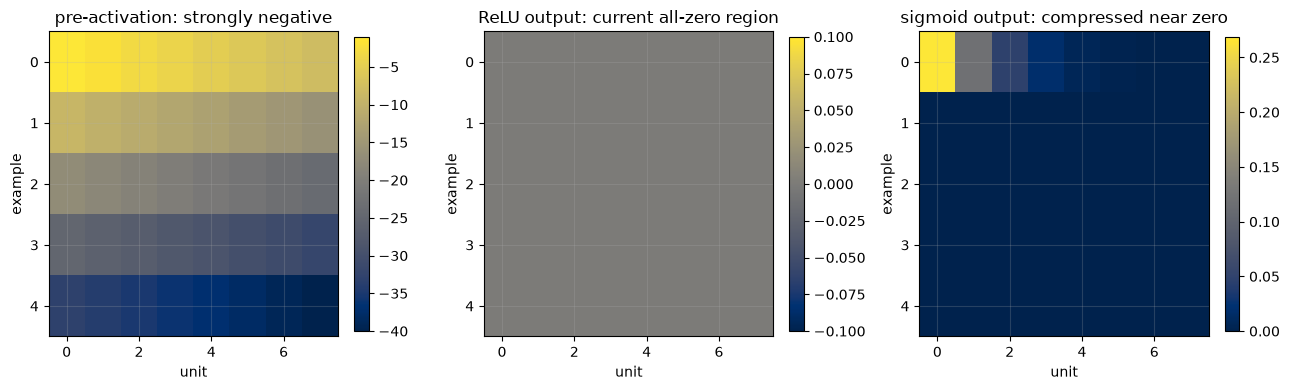

In [10]:
strongly_negative = -np.arange(1.0, 41.0).reshape(5, 8)
negative_relu = relu(strongly_negative)
sigmoid_tail_change = float(np.diff(sigmoid(np.array([8.0, 12.0])))[0])
tanh_tail_change = float(np.diff(tanh_activation(np.array([8.0, 12.0])))[0])
assert negative_relu.shape == (5, 8)
assert np.count_nonzero(negative_relu) == 0
assert sigmoid_tail_change < 1e-3 and tanh_tail_change < 1e-3
print(f"Dead-region evidence: ReLU nonzero outputs = {np.count_nonzero(negative_relu)}/{negative_relu.size}")
print(f"Saturation evidence: sigmoid(8)->sigmoid(12) change = {sigmoid_tail_change:.6f}")
print(f"Saturation evidence: tanh(8)->tanh(12) change = {tanh_tail_change:.9f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
images = [
    (strongly_negative, "pre-activation: strongly negative"),
    (negative_relu, "ReLU output: current all-zero region"),
    (sigmoid(strongly_negative), "sigmoid output: compressed near zero"),
]
for ax, (values, title) in zip(axes, images):
    image = ax.imshow(values, aspect="auto", cmap="cividis")
    ax.set(title=title, xlabel="unit", ylabel="example")
    fig.colorbar(image, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

### Instructor Answer: Saturation and Current ReLU Region

**What happened?** Sigmoid/tanh curves flatten at large magnitudes; all 40 supplied negative values
became zero under ReLU.  
**Why?** Bounded activations approach asymptotes, while ReLU is exactly zero for negative inputs.  
**Concept:** Activation ranges expose information compression and current zero regions.

**Misconception to correct:** This batch does not prove a unit is permanently dead. Different inputs or
future parameter values could move its pre-activation positive. Ask, "For which observed inputs?"


## Predict: Multiclass Softmax and Its Axis

The output has three class logits per example. Predict the shape and the sum that should equal one for each example. Then predict what a softmax normalized down axis `0` would sum instead. Explain why both versions can return shape `(5, 3)` even though only one matches the task semantics.

In [11]:
softmax_predictions = {
    "logit_and_probability_shape": "Both are (5,3).",
    "correct_axis_sums": "Each example row sums to 1 when classes are normalized on axis 1.",
    "wrong_axis_sums": "Each class column sums to 1 when examples are incorrectly normalized on axis 0.",
    "why_shape_is_insufficient": "Both operations preserve (5,3), so a per-example row-sum invariant is required.",
}
assert all(value.strip() for value in softmax_predictions.values())


## Modify: Implement Stable Row-Wise Softmax

Complete `softmax`. Normalize classes within each example (`axis=1`) and subtract a per-row maximum before exponentiating. Preserve `(batch, classes)` shape.

In [12]:
def softmax(logits):
    logits = np.asarray(logits, dtype=float)
    if logits.ndim != 2:
        raise ValueError(f"Expected (batch, classes) logits; got {logits.shape}")
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exponentials = np.exp(shifted)
    return exponentials / exponentials.sum(axis=1, keepdims=True)


In [13]:
A1 = relu(Z1)
logits = dense(A1, W2, b2)
probabilities = softmax(logits)

assert A1.shape == (5, 8)
assert logits.shape == (5, 3)
assert probabilities.shape == (5, 3)
assert np.all(np.isfinite(probabilities))
assert np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-6)
print("Z1/A1/logits/probabilities:", Z1.shape, A1.shape, logits.shape, probabilities.shape)
print("Softmax row sums:", np.round(probabilities.sum(axis=1), 8))

Z1/A1/logits/probabilities: (5, 8) (5, 8) (5, 3) (5, 3)
Softmax row sums: [1. 1. 1. 1. 1.]


## Break It: Wrong-Axis Softmax

The supplied function below is deliberately wrong for this task: it normalizes across examples. It should run and preserve shape. The diagnostic assertion is expected to fail, and the cell catches that expected failure so you can inspect its message before recovering with your row-wise implementation.

In [14]:
def wrong_axis_softmax(logits):
    shifted = logits - np.max(logits, axis=0, keepdims=True)
    exponentials = np.exp(shifted)
    return exponentials / exponentials.sum(axis=0, keepdims=True)


wrong_probabilities = wrong_axis_softmax(logits)
assert wrong_probabilities.shape == probabilities.shape
expected_failure_observed = False
try:
    assert np.allclose(wrong_probabilities.sum(axis=1), 1.0, atol=1e-6), (
        "Per-example row sums are not one; check the softmax normalization axis."
    )
except AssertionError as error:
    expected_failure_observed = True
    print("Expected deliberate failure:", error)

print("Wrong-axis row sums:", np.round(wrong_probabilities.sum(axis=1), 6))
print("Wrong-axis column sums:", np.round(wrong_probabilities.sum(axis=0), 6))
assert expected_failure_observed, "The deliberate wrong-axis case should violate row normalization."

Expected deliberate failure: Per-example row sums are not one; check the softmax normalization axis.
Wrong-axis row sums: [0.647134 0.635321 0.406391 0.715075 0.596079]
Wrong-axis column sums: [1. 1. 1.]


### Instructor Answer: Wrong-Axis Detective

**Expected deterministic evidence:** correct row sums are all `1`; the wrong-axis row sums are
approximately `[0.6471, 0.6353, 0.4064, 0.7151, 0.5961]`, while each wrong-axis column sums to `1`.

**What happened?** The defective code ran and returned the expected shape, but violated per-example
probability semantics.  
**Why?** It normalized each class down the batch instead of classes within a row.  
**Concept:** Shape checks catch interface errors; semantic invariants catch plausible-looking wrong axes.

**Hint ladder:** Label the axes, state what must sum to one, then inspect row and column totals before
revealing the implementation.


In [15]:
extreme_logits = np.array([
    [1_000_000.0, 1_000_001.0, 999_999.0],
    [-1_000_000.0, -1_000_001.0, -999_999.0],
])
recovered_probabilities = softmax(extreme_logits)
assert recovered_probabilities.shape == (2, 3)
assert np.all(np.isfinite(recovered_probabilities))
assert np.allclose(recovered_probabilities.sum(axis=1), 1.0, atol=1e-6)
print("Recovery row sums under extreme logits:", recovered_probabilities.sum(axis=1))

Recovery row sums under extreme logits: [1. 1.]


## Diagnose and Explain

Use observed arrays or plots to answer:

1. Why is the parameter count independent of five examples?
2. What evidence shows one bias vector broadcasting across rows?
3. Where did sigmoid/tanh compress changes, and what did ReLU do to the supplied negative region?
4. Why does the all-zero ReLU result describe the current input region rather than every possible input?
5. Which invariant caught the softmax defect that shape checks missed?
6. How do hidden-layer and multiclass-output roles differ?

In [16]:
explanation = {
    "batch_vs_parameters": "Five examples add activation rows but do not change W1, b1, W2, or b2; the count stays 67.",
    "broadcast_evidence": "Z1 - X@W1 reproduced the same b1 vector in every row.",
    "activation_evidence": "Sigmoid/tanh compressed extreme changes; ReLU mapped all 40 supplied negative values to zero.",
    "current_vs_permanent_relu": "The zero result covers this negative matrix only; other inputs or parameters could produce positive pre-activations.",
    "softmax_invariant": "Per-example probability row sums must equal 1; the axis-0 implementation failed that invariant despite shape (5,3).",
    "hidden_vs_output_role": "Hidden activations change representation elementwise; multiclass softmax couples class logits into one distribution per example.",
}
assert all(value.strip() for value in explanation.values())
assert parameter_count == 67
assert Z1.shape == A1.shape == (5, 8)
assert logits.shape == probabilities.shape == (5, 3)
assert np.allclose(probabilities.sum(axis=1), 1.0, atol=1e-6)
assert expected_failure_observed and np.count_nonzero(negative_relu) == 0
print("LAB-D1-03 checkpoint passed: 67 parameters, dense broadcasting, activation evidence, and softmax failure/recovery.")


LAB-D1-03 checkpoint passed: 67 parameters, dense broadcasting, activation evidence, and softmax failure/recovery.


## Troubleshooting and Instructor Operations

| Symptom | Likely cause | Recovery |
|---|---|---|
| Parameter count is not 67 | A bias vector was skipped or batch size was counted | Count `d_in*d_out + d_out` for both dense layers |
| Dense matrix error | Examples or weights use the wrong orientation | Restore `(B,d_in) @ (d_in,d_out)` |
| Bias result has an extra dimension | Bias was reshaped inconsistently | Use the supplied `(d_out,)` vector and NumPy row broadcasting |
| Sigmoid overflows | Direct exponentiation used an unstable sign | Branch by sign and rerun the $10^6$ magnitude check |
| Wrong-axis cell prints a failure | This is the intended diagnostic | Compare row/column sums, then verify recovery with `softmax` |
| Wrong-axis cell does not fail | The diagnostic summed the same wrong axis | Assert the per-example row sums on `axis=1` |
| Softmax produces NaN or infinity | Per-row maximum was not subtracted | Shift each row before exponentiating |
| Plot output is unavailable | Backend or live-render issue | Use the printed activation table, tail deltas, and probability sums |

**Instructor demo notes:** Preserve each prediction before revealing evidence. For the dense demo, point to the repeated `broadcast_delta` rows. For activation behavior, pair the curves with the printed tail deltas. For softmax, ask learners to name the semantic class axis before showing numeric axis `1`.

**Fast recovery:** If implementation time runs short, provide the completed stable sigmoid or plotting shell, but retain the parameter-count reasoning, strongly negative ReLU diagnosis, wrong-axis failure/recovery, and six-part evidence explanation. If live rendering fails, use stored outputs and continue the prediction/debrief cycle.

**Misconceptions to route:** Batch entries are not trainable parameters; elementwise shape preservation does not imply unchanged values; row and column softmax have the same shape but different semantics; a current all-zero ReLU region is not proof of permanent unit death.

**Alternative valid implementations:** Accept any dense count loop or vectorized expression that includes both bias vectors; any stable sigmoid that stays finite at extreme inputs; and any stable row-wise softmax that normalizes classes per example and passes shape, finiteness, and row-sum invariants. Equivalent plots or tables are valid when they expose the same evidence.

**Environment recovery:** Select a CPU kernel with NumPy and matplotlib, restart after package changes, and rerun from the top. The notebook has no data, file, network, GPU, or previous-lab dependency. A hosted Colab run remains a separate validation claim.

## Takeaways

- The `4 -> 8 -> 3` architecture contains 67 trainable parameters, independent of batch size.
- Dense bias broadcasting reuses one parameter vector across examples.
- Elementwise activations preserve shape but produce different ranges and failure evidence.
- Stable probability functions must remain finite under extreme inputs.
- Shape correctness is necessary but not sufficient; semantic invariants expose wrong axes.

The required core lab is complete at the checkpoint above.

---

## OPTIONAL EXTENSION: Leaky ReLU

**Everything below is independently skippable.** Removing this cell and every later optional Leaky ReLU evidence cell does not affect the core checkpoint, variables, figures, or outputs above.

Before the optional comparison, predict which outputs differ from ReLU at `negative_slope=0.1`, which values and shapes remain invariant at slope `0.02`, and what evidence reveals a nonzero negative slope.

**Optional hint ladder:** (1) Split inputs by sign. (2) Keep the nonnegative branch unchanged. (3) Compare the same negative input at both slopes. (4) Use `np.where` for a compact elementwise implementation.

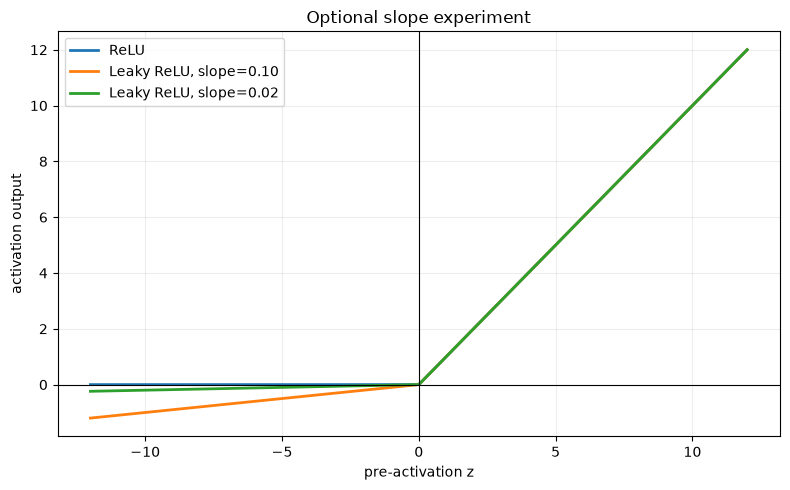

   input       ReLU    Leaky .10    Leaky .02
   -12.0     0.0000      -1.2000      -0.2400
    -3.0     0.0000      -0.3000      -0.0600
     0.0     0.0000       0.0000       0.0000
     3.0     3.0000       3.0000       3.0000
    12.0    12.0000      12.0000      12.0000
Optional Leaky ReLU extension checkpoint passed.


In [17]:
optional_leaky_relu_predictions = {
    "relu_comparison": "Only negative inputs differ: ReLU returns 0, while slope 0.10 returns 0.10 times each negative input.",
    "slope_change_invariants": "Shape, zero, and positive outputs stay fixed; only negative output magnitudes change.",
    "evidence_of_negative_slope": "The negative branch is a visible line below zero, and the table has nonzero negative outputs.",
}
assert all(value.strip() for value in optional_leaky_relu_predictions.values())


def leaky_relu(values, negative_slope=0.1):
    values = np.asarray(values, dtype=float)
    return np.where(values >= 0.0, values, float(negative_slope) * values)


leaky_default = leaky_relu(activation_inputs, negative_slope=0.1)
leaky_shallow = leaky_relu(activation_inputs, negative_slope=0.02)
relu_outputs = relu(activation_inputs)

assert leaky_default.shape == leaky_shallow.shape == relu_outputs.shape == activation_inputs.shape
assert np.all(np.isfinite(leaky_default)) and np.all(np.isfinite(leaky_shallow))
assert np.allclose(leaky_default[activation_inputs >= 0], relu_outputs[activation_inputs >= 0])
assert np.allclose(leaky_shallow[activation_inputs >= 0], relu_outputs[activation_inputs >= 0])
assert not np.allclose(leaky_default[activation_inputs < 0], leaky_shallow[activation_inputs < 0])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(activation_inputs, relu_outputs, linewidth=2, label="ReLU")
ax.plot(activation_inputs, leaky_default, linewidth=2, label="Leaky ReLU, slope=0.10")
ax.plot(activation_inputs, leaky_shallow, linewidth=2, label="Leaky ReLU, slope=0.02")
ax.axhline(0.0, color="black", linewidth=0.8)
ax.axvline(0.0, color="black", linewidth=0.8)
ax.set(title="Optional slope experiment", xlabel="pre-activation z", ylabel="activation output")
ax.legend()
plt.tight_layout()
plt.show()

print(f"{'input':>8} {'ReLU':>10} {'Leaky .10':>12} {'Leaky .02':>12}")
for index, value in enumerate(inspection_values):
    relu_value = relu(inspection_values)[index]
    default_value = leaky_relu(inspection_values, 0.1)[index]
    shallow_value = leaky_relu(inspection_values, 0.02)[index]
    print(f"{value:>8.1f} {relu_value:>10.4f} {default_value:>12.4f} {shallow_value:>12.4f}")

optional_leaky_relu_interpretation = {
    "negative_input_comparison": "ReLU returns zero for negative inputs; Leaky ReLU retains nonzero negative outputs proportional to the selected slope.",
    "slope_experiment_evidence": "At -12, slopes 0.10 and 0.02 return -1.20 and -0.24; zero, positive outputs, and shapes are unchanged.",
    "limits_of_the_comparison": "This deterministic function comparison exposes branch behavior but cannot establish universal training or accuracy superiority.",
}
assert all(value.strip() for value in optional_leaky_relu_interpretation.values())
print("Optional Leaky ReLU extension checkpoint passed.")

### Optional Instructor Answer

**What happened?** At input `-12`, ReLU returns `0`, slope `0.10` returns `-1.2`, and slope `0.02` returns `-0.24`. At zero and positive inputs, all three outputs agree; every output array retains shape `(401,)`.

**Why?** Leaky ReLU changes only the negative branch from slope zero to a configured small positive slope. Reducing that slope moves negative outputs closer to zero without affecting the nonnegative branch.

**Concept:** A one-variable comparison isolates a mechanism. This evidence describes function behavior; it does not show that Leaky ReLU is universally better than ReLU.

**Common wrong answers:** A negative output is not a negative slope, and a nonzero negative branch does not guarantee better model accuracy. No training experiment occurs here.

**Acceptable alternatives:** Any positive slope pair is valid if the same inputs are used, negative outputs differ as predicted, nonnegative outputs and shapes stay invariant, and the interpretation avoids universal performance claims.